# Performing gradient descent in regression

Import the required libraries:

In [1]:
import warnings
warnings.filterwarnings('ignore')
import random
import math
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

Generate some random data points with 500 rows and 2 columns
(x and y) and use them for training:

In [2]:
data = np.random.randn(500, 2)
print(data[0])

[-0.20135004  0.12594373]


We know that the equation of a simple linear regression is expressed as follows:
f(x) = mx + b

Thus, we have two parameters, and . We store both of these parameters in an array called theta. First, we initialize theta with zeros, as follows:

In [3]:
theta = np.zeros(2)

The theta[0] function represents the value of , while the theta[1] function represents the value of :

In [4]:
print(theta)


[0. 0.]


Let's define the loss function:

In [7]:
def loss_function(data,theta):
  m = theta[0]
  b = theta[1]
  loss = 0

  for i in range(0, len(data)):
    x = data[i, 0]
    y = data[i, 1]

    y_hat = (m*x + b)
    loss = loss + ((y - (y_hat)) ** 2)

  mse = loss / float(len(data))

  return mse


We need to minimize this loss. In order to minimize the loss, we need to calculate the gradient of the loss function, , with respect to the model parameters, and , and update the parameter according to the parameter update rule.

In [8]:
def compute_gradients(data, theta):
  gradients = np.zeros(2)
  N = float(len(data))
  m = theta[0]
  b = theta[1]
  for i in range(0, len(data)):
    x = data[i, 0]
    y = data[i, 1]
    gradients[0] += - (2 / N) * x * (y - (( m* x) + b))
    gradients[1] += - (2 / N) * (y - ((theta[0] * x) + b))

  epsilon = 1e-6
  gradients = np.divide(gradients, N + epsilon)
  return gradients

In [9]:
compute_gradients(data,theta)

array([ 0.00012954, -0.00018396])

Now that we've computed the gradients, we need to update our model parameters according to our update rule,

In [11]:
num_iterations=50000

#Learning rate
lr=1e-2

#Store loss on each iteration
loss=[]

In [12]:
theta = np.zeros(2)

for t in range(num_iterations):

    #compute gradients
    gradients = compute_gradients(data, theta)

    #update parameter
    theta = theta - (lr*gradients)

    #store the loss
    loss.append(loss_function(data,theta))


Now, we need to plot the loss (Cost) function:

Text(0.5, 1.0, 'Gradient Descent')

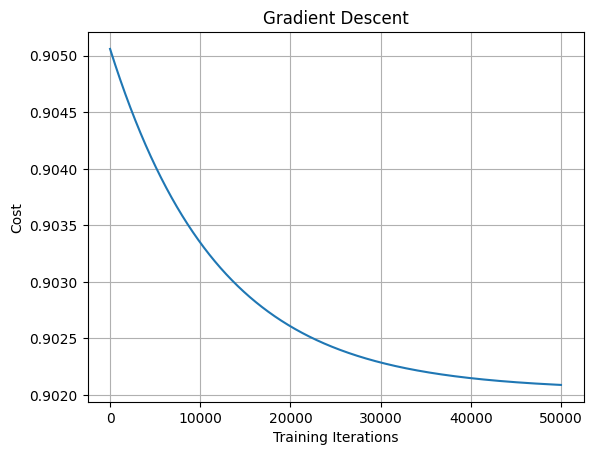

In [13]:
plt.plot(loss)
plt.grid()
plt.xlabel('Training Iterations')
plt.ylabel('Cost')
plt.title('Gradient Descent')

# Gradient descent versus stochastic gradient descent


Unlike gradient descent, we don't have to wait to update the parameter of the
model after iterating all the data points in our training set, we just update the parameters of the model after iterating through every single data point in our training set.

Since we update the parameters of the model in SGD after iterating every
single data point, it will learn the optimal parameter of the model faster
compared to gradient descent, and this will minimize the training time.

There is also another variant of gradient descent called mini-batch gradient descent. It takes the pros of both vanilla gradient descent and stochastic gradient descent. In SGD, we saw that we update the parameter of the model for every training sample. However, in mini-batch gradient descent, instead of updating the parameters after iterating each training sample, we update the parameters after iterating some batches of data points. Let's say the batch size is 50, which means that we update the parameter of the model after iterating through 50 data points instead of updating the parameter after iterating through each individual data point.



*   **Gradient Descent**: Updates the parameters of the model after iterating through all the data points in the training set
*   **Stochastic Gradient Descent**: Updates the parameter of the model after iterating through every single data point in training set.
* **Mini-batch Gradient Descent**: Updates parameters of the model after iterating n number of data points in the training set



In [14]:
def minibatch(data, theta, lr=1e-2, minibatch_ratio=0.01, num_iterations=1000):
    """
    Performs mini-batch gradient descent on the given data.

    Parameters:
    data: numpy array of shape (n_samples, n_features + 1) where the last column is the target
    theta: numpy array of shape (n_features, 1) - model parameters
    lr: learning rate (default: 0.01)
    minibatch_ratio: ratio of data to use in each mini-batch (default: 0.01)
    num_iterations: number of iterations to perform (default: 1000)

    Returns:
    theta: updated model parameters
    """
    # Calculate mini-batch size
    minibatch_size = int(math.ceil(len(data) * minibatch_ratio))

    # Perform gradient descent for the specified number of iterations
    for t in range(num_iterations):
        # Randomly select indices for the mini-batch
        sample_indices = random.sample(range(len(data)), minibatch_size)

        # Sample the data based on the selected indices
        sample_data = data[sample_indices, :]

        # Compute gradients for the sampled data
        grad = compute_gradients(sample_data, theta)

        # Update model parameters
        theta = theta - (lr * grad)

    return theta

In [15]:
def compute_gradients(data, theta):
    """
    Computes the gradients of the loss function with respect to theta.

    Parameters:
    data: numpy array of shape (n_samples, n_features + 1) where the last column is the target
    theta: numpy array of shape (n_features, 1) - model parameters

    Returns:
    gradients: numpy array of shape (n_features, 1)
    """
    # Separate features and target
    X = data[:, :-1]
    y = data[:, -1].reshape(-1, 1)

    # Number of samples
    m = X.shape[0]

    # Compute predictions
    predictions = X @ theta

    # Compute error
    error = predictions - y

    # Compute gradients (for mean squared error)
    gradients = (1/m) * (X.T @ error)

    return gradients


In [16]:
# Example usage
n_samples = 1000
n_features = 5
X = np.random.randn(n_samples, n_features)
true_theta = np.random.randn(n_features, 1)
y = X @ true_theta + 0.1 * np.random.randn(n_samples, 1)

# Combine features and target
data = np.hstack((X, y))

# Initialize theta
initial_theta = np.zeros((n_features, 1))

# Run mini-batch gradient descent
optimized_theta = minibatch(data, initial_theta, lr=0.01, minibatch_ratio=0.1, num_iterations=1000)

print("True theta:", true_theta.flatten())
print("Optimized theta:", optimized_theta.flatten())

True theta: [-0.40872354  0.16724259 -0.12829842  0.95474241 -0.75380243]
Optimized theta: [-0.40840734  0.16370335 -0.12728372  0.95452203 -0.75139558]


# Momentum-based Gradient Descent

Since we update parameters after iterating every n number of data points, the direction of the update will have some variance, and this leads to oscillations in every gradient step. Due to this oscillation, it is hard to reach convergence and it slows down the process of attaining it.

To alleviate this, we introduce a new technique called momentum. If we can understand what the right direction is for gradient steps to attain convergence faster, then we can make our gradient steps navigate in that direction and reduce the oscillation.

We do this by taking a fraction of the parameter update from the previous gradient step and add it to the current gradient step.

In [18]:
def momentum(data, theta, lr=1e-2, gamma=0.9, num_iterations=1000):
    velocity = np.zeros_like(theta)

    for i in range(num_iterations):
        grad = compute_gradient(data, theta)  # You need to define this separately
        velocity = gamma * velocity + lr * grad
        theta -= velocity

    return theta